# News Article Classification using NLP

This project is part of the coursework for **Data Mining (CAS764)** (Spring 2016) under the guidance of **Prof. Ramadoss**.
It is submitted in fulfillment of the requirements for the degree of **Master of Science (M.Sc.) in Computer Science** at the **Department of Computer Applications, National Institute of Technology, Tiruchirappalli**.

## Project Overview

This project aims to develop a machine learning model for classifying news articles into predefined categories using Natural Language Processing (NLP) techniques. The primary objective is to process raw text data from a standard dataset, transform it into numerical features suitable for machine learning, train a robust classification model, and evaluate its performance.

**Key Components:**

**Dataset:** Utilizing the widely-used 20 Newsgroups dataset.

**Preprocessing:** Cleaning and standardizing text data.

**Feature Extraction:** Converting text into numerical vectors using TF-IDF with n-grams.

**Modeling:** Training a Linear Support Vector Machine (SVM) classifier.

**Evaluation:** Assessing model performance using accuracy, classification report, and confusion matrix.

**Analysis:** Exploring data characteristics and identifying influential features.

The project demonstrates a fundamental approach to text classification and provides insights into handling and modeling text data.


# 1. Setup and Data Loading

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
from collections import Counter
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("Libraries imported.")


Libraries imported.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Data Loading

In [ ]:
print("\nLoading 20 Newsgroups dataset...")
try:
    newsgroups_data = fetch_20newsgroups(subset='all', categories=None,
                                         shuffle=True, random_state=42,
                                         remove=('headers', 'footers', 'quotes'))

    X = newsgroups_data.data
    y = newsgroups_data.target
    target_names = newsgroups_data.target_names

    print("Dataset loaded successfully.")
    print(f"Number of documents: {len(X)}")
    print(f"Number of categories: {len(target_names)}")

except Exception as e:
    print(f"Error loading dataset: {e}")


Loading 20 Newsgroups dataset...
Dataset loaded successfully.
Number of documents: 18846
Number of categories: 20


# 2. Data Analysis and Visualization

## 2.1 Distribution of Documents per Category


Analyzing document distribution per category...


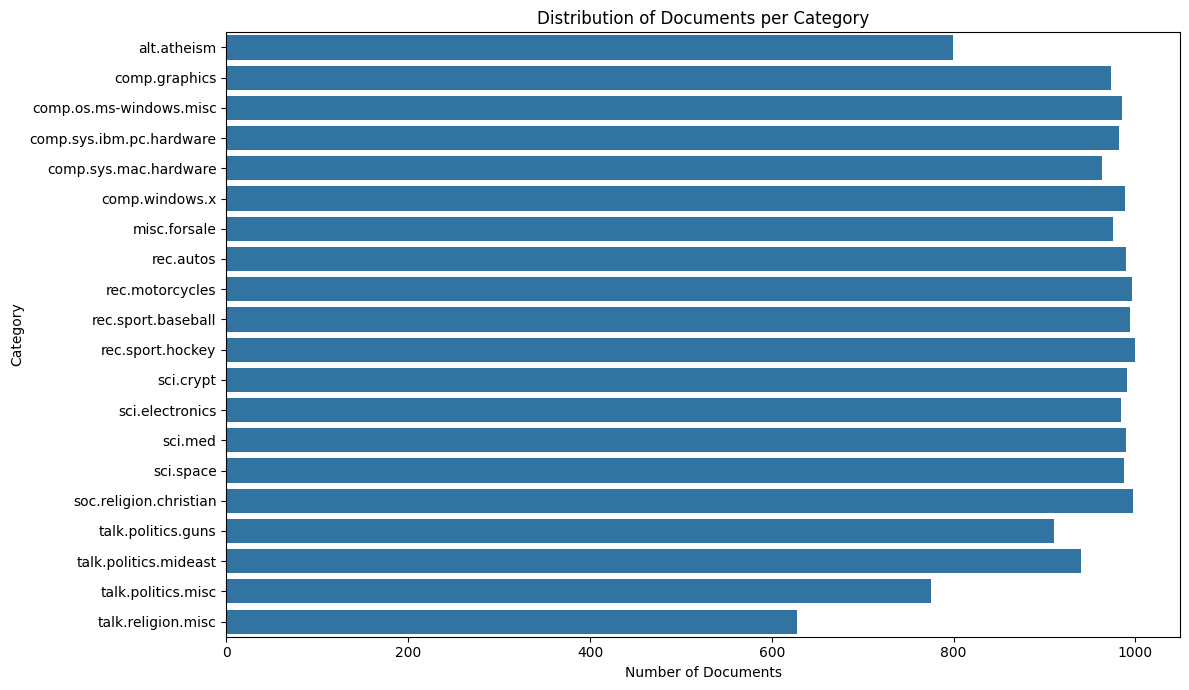

Category distribution plot displayed.


In [ ]:
print("\nAnalyzing document distribution per category...")
plt.figure(figsize=(12, 7))
sns.countplot(y=y, order=np.arange(len(target_names)))
plt.yticks(ticks=np.arange(len(target_names)), labels=target_names)
plt.title('Distribution of Documents per Category')
plt.xlabel('Number of Documents')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
print("Category distribution plot displayed.")

## 2.2 Document Length Analysis


Analyzing document length distribution...


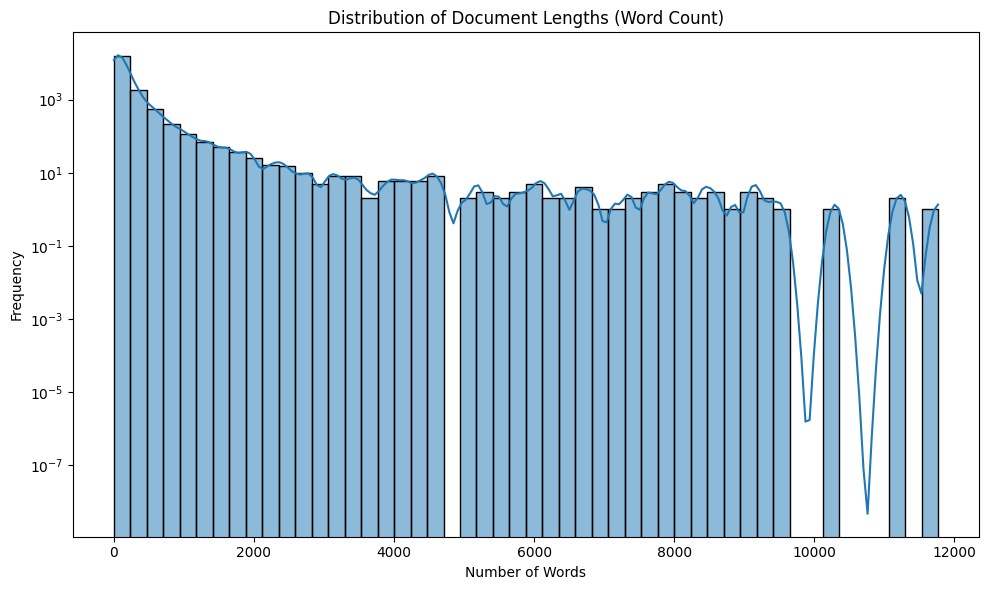

Document length distribution plot displayed.
Average document length: 181.64 words
Median document length: 83.00 words
Max document length: 11765 words


In [ ]:
print("\nAnalyzing document length distribution...")
document_lengths = [len(doc.split()) for doc in X]

plt.figure(figsize=(10, 6))
sns.histplot(document_lengths, bins=50, kde=True)
plt.title('Distribution of Document Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.yscale('log')
plt.tight_layout()
plt.show()
print("Document length distribution plot displayed.")
print(f"Average document length: {np.mean(document_lengths):.2f} words")
print(f"Median document length: {np.median(document_lengths):.2f} words")
print(f"Max document length: {np.max(document_lengths)} words")


## 2.3 Most Common Words

In [ ]:
all_words_before = ' '.join(X).split()
most_common_before = Counter(all_words_before).most_common(20)

print("Top 20 most common words:")
for word, count in most_common_before:
    print(f"- {word}: {count}")

Top 20 most common words:
- the: 153574
- to: 83965
- of: 75111
- a: 65521
- and: 64420
- in: 45448
- is: 45404
- I: 44740
- that: 41057
- for: 29222
- you: 22916
- it: 22828
- on: 21334
- be: 21202
- have: 20583
- with: 19744
- are: 19506
- not: 17396
- The: 16477
- as: 16344


# 3. Preprocessing

In [ ]:
print("Applying preprocessing to text data...")

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    if not text:
        return ""

    tokens = text.split()

    if not tokens:
        return ""

    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]

    return ' '.join(tokens)

X_processed = [preprocess_text(doc) for doc in X]

print("Preprocessing complete.")


Applying preprocessing to text data...
Preprocessing complete.


In [ ]:
print("\nAnalyzing most common words (after preprocessing)")
all_words_after = ' '.join(X_processed).split()
most_common_after = Counter(all_words_after).most_common(20)

print("Top 20 most common words (after preprocessing):")
for word, count in most_common_after:
    print(f"- {word}: {count}")


Analyzing most common words (after preprocessing)
Top 20 most common words (after preprocessing):
- use: 11434
- one: 10723
- would: 10155
- x: 7543
- get: 7380
- like: 7222
- peopl: 6495
- dont: 6432
- know: 6422
- time: 5770
- also: 5579
- think: 5550
- make: 4976
- say: 4966
- go: 4708
- work: 4650
- system: 4231
- could: 4162
- year: 4150
- well: 4130


# 4. Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.25, random_state=42, stratify=y)

print(f"Data split complete. Train size: {len(X_train)}, Test size: {len(X_test)}")


Data split complete. Train size: 14134, Test size: 4712


# 5. Feature Extaction (TF-IDF with N-grams)

In [ ]:
print("Extracting features using TF-IDF (with N-grams)...")

ngram_range=(1, 2)
ngram_range=(1, 3)
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF feature extraction complete.")
print(f"Training data shape: {X_train_tfidf.shape} (Number of documents, Number of features)")
print(f"Test data shape: {X_test_tfidf.shape}")
print(f"Vocabulary size (max_features): {len(tfidf_vectorizer.vocabulary_)}")
print(f"Sparsity of training matrix: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.6f}")


Extracting features using TF-IDF (with N-grams)...
TF-IDF feature extraction complete.
Training data shape: (14134, 20000) (Number of documents, Number of features)
Test data shape: (4712, 20000)
Vocabulary size (max_features): 20000
Sparsity of training matrix: 0.003216


# 6. Model Selection and Training (Linear SVM)

In [ ]:
model = LinearSVC(random_state=42)
model.fit(X_train_tfidf, y_train)

print("Model training complete.")


Model training complete.


# 7. Model Evaluation


Accuracy: 0.7410865874363328

Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.64      0.58      0.61       200
           comp.graphics       0.72      0.70      0.71       243
 comp.os.ms-windows.misc       0.70      0.67      0.69       246
comp.sys.ibm.pc.hardware       0.67      0.67      0.67       245
   comp.sys.mac.hardware       0.73      0.71      0.72       241
          comp.windows.x       0.81      0.84      0.82       247
            misc.forsale       0.78      0.73      0.76       244
               rec.autos       0.50      0.82      0.62       248
         rec.motorcycles       0.81      0.71      0.75       249
      rec.sport.baseball       0.90      0.82      0.86       249
        rec.sport.hockey       0.88      0.90      0.89       250
               sci.crypt       0.86      0.82      0.84       248
         sci.electronics       0.71      0.70      0.71       246
                 sci

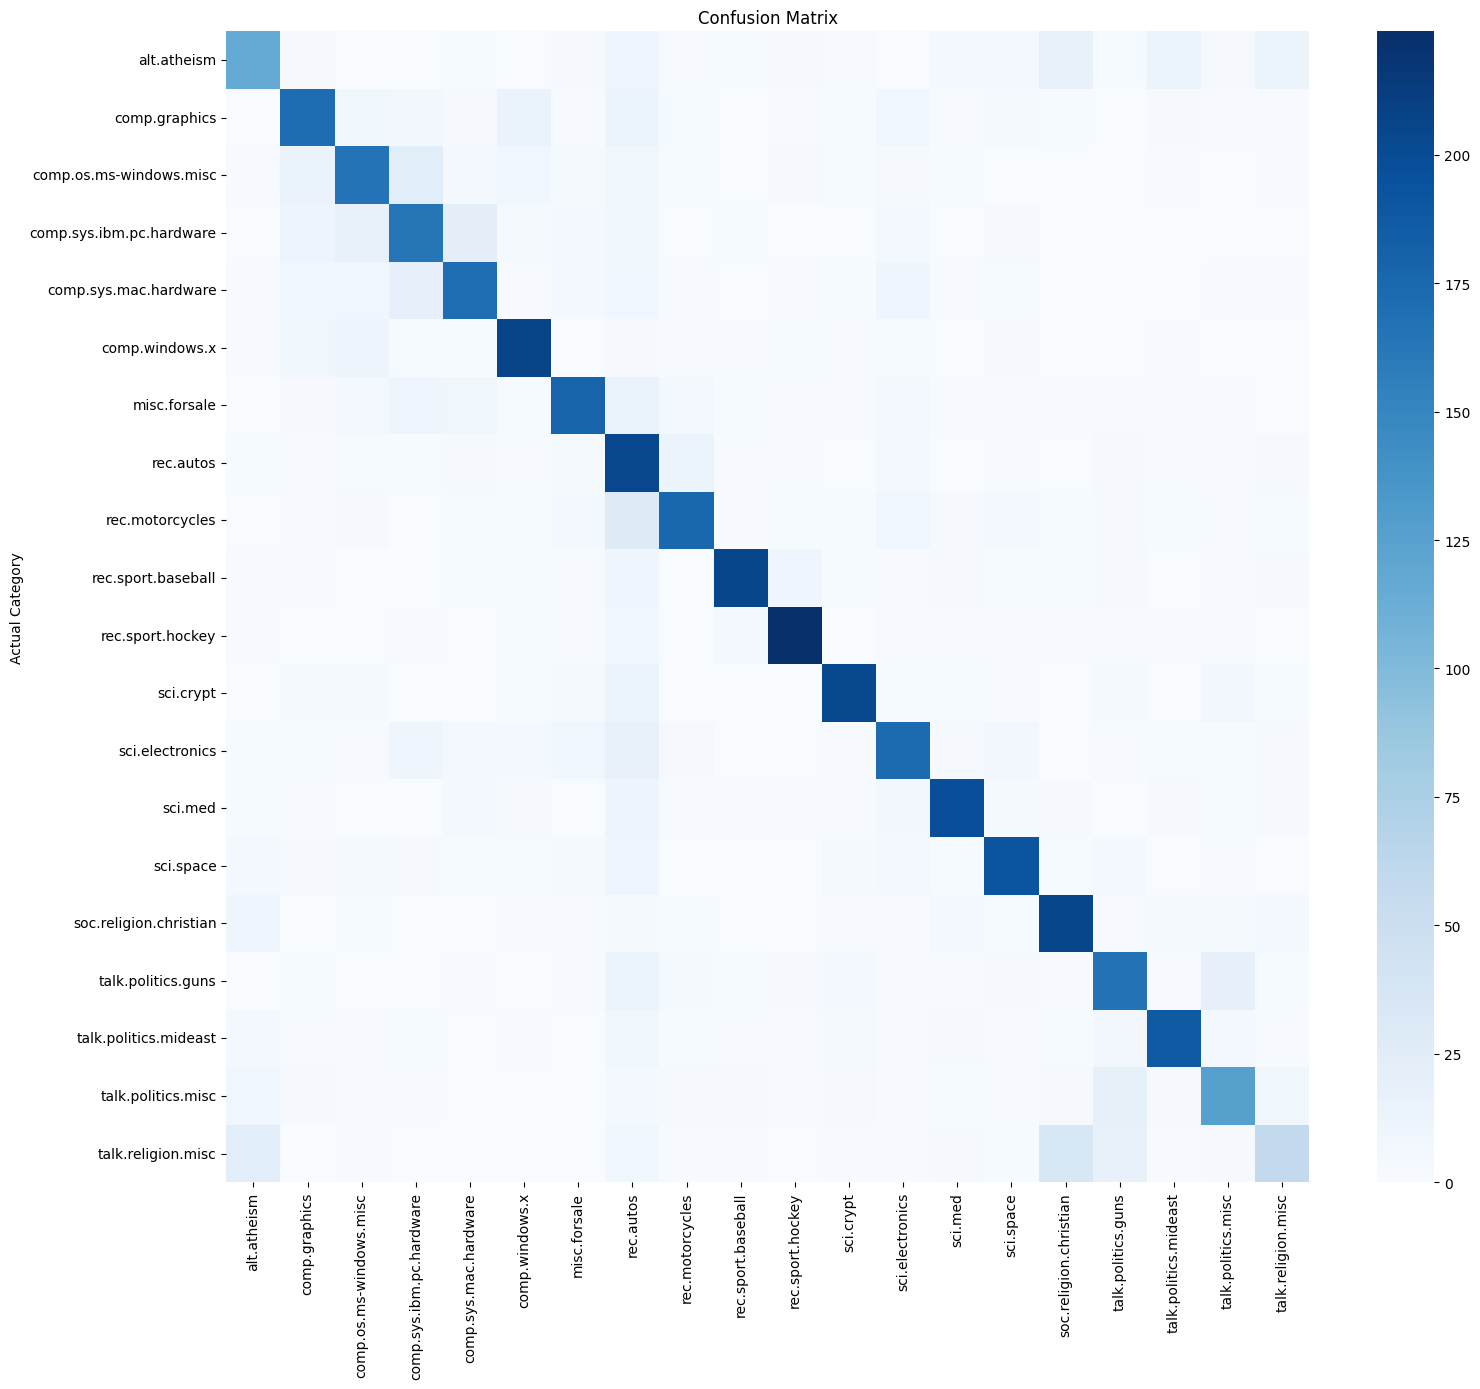

Confusion Matrix plot displayed.


In [ ]:
y_pred = model.predict(X_test_tfidf)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))
print("\nPlotting Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual Category')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
print("Confusion Matrix plot displayed.")



# 8. Model Analysis: Top Features per Category

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
n_components = 10

print(f"\nTop {n_components} features per category:")

for i, category in enumerate(target_names):
    coefs = model.coef_[i]
    top_n_pos_indices = coefs.argsort()[-n_components:]
    top_n_neg_indices = coefs.argsort()[:n_components]

    print(f"\nCategory: {category}")
    print("  Most influential POSITIVE features:")
    for j in reversed(top_n_pos_indices):
         print(f"    - {feature_names[j]}: {coefs[j]:.4f}")

    print("  Most influential NEGATIVE features:")
    for j in top_n_neg_indices:
         print(f"    - {feature_names[j]}: {coefs[j]:.4f}")



Top 10 features per category:

Category: alt.atheism
  Most influential POSITIVE features:
    - atheist: 2.3269
    - motto: 2.1316
    - islam: 2.0441
    - bobbi: 1.9962
    - religion: 1.8410
    - quran: 1.7514
    - aa: 1.6528
    - cruel: 1.6241
    - loan: 1.6110
    - nicknam: 1.6065
  Most influential NEGATIVE features:
    - christian: -1.1288
    - sin: -1.0313
    - may: -0.9476
    - agnost: -0.9424
    - hudson: -0.9391
    - jew: -0.9031
    - man: -0.8992
    - christ: -0.8805
    - doctrin: -0.8421
    - proven: -0.8303

Category: comp.graphics
  Most influential POSITIVE features:
    - graphic: 3.1458
    - compgraph: 2.4702
    - imag: 2.3190
    - siggraph: 2.1085
    - polygon: 2.1061
    - pov: 2.0441
    - hacker: 2.0200
    - tiff: 1.9929
    - viewer: 1.8770
    - vesa: 1.8242
  Most influential NEGATIVE features:
    - window: -1.6119
    - monitor: -1.3293
    - disk: -1.1316
    - xr: -1.0203
    - drive: -0.9444
    - motif: -0.9047
    - encrypt: -0.884